In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [3]:
df = pd.read_csv('data/churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns, drop_first=True)

print("Shape:", df.shape)
df.head()

Shape: (7032, 31)


C:\Users\umang\AppData\Local\Temp\ipykernel_26352\316456297.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns, drop_first=True)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


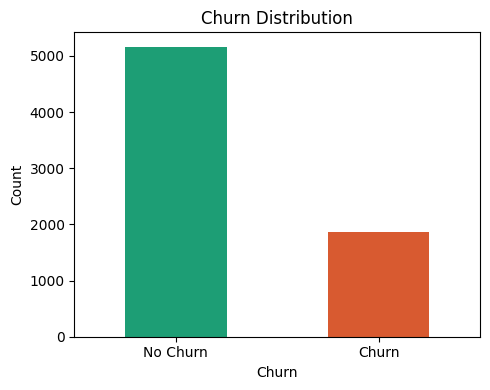

In [4]:
plt.figure(figsize=(5,4))
df['Churn'].value_counts().plot(kind='bar', color=['#1D9E75','#D85A30'])
plt.title('Churn Distribution')
plt.xticks([0,1], ['No Churn','Churn'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('images/churn_distribution.png')
plt.show()

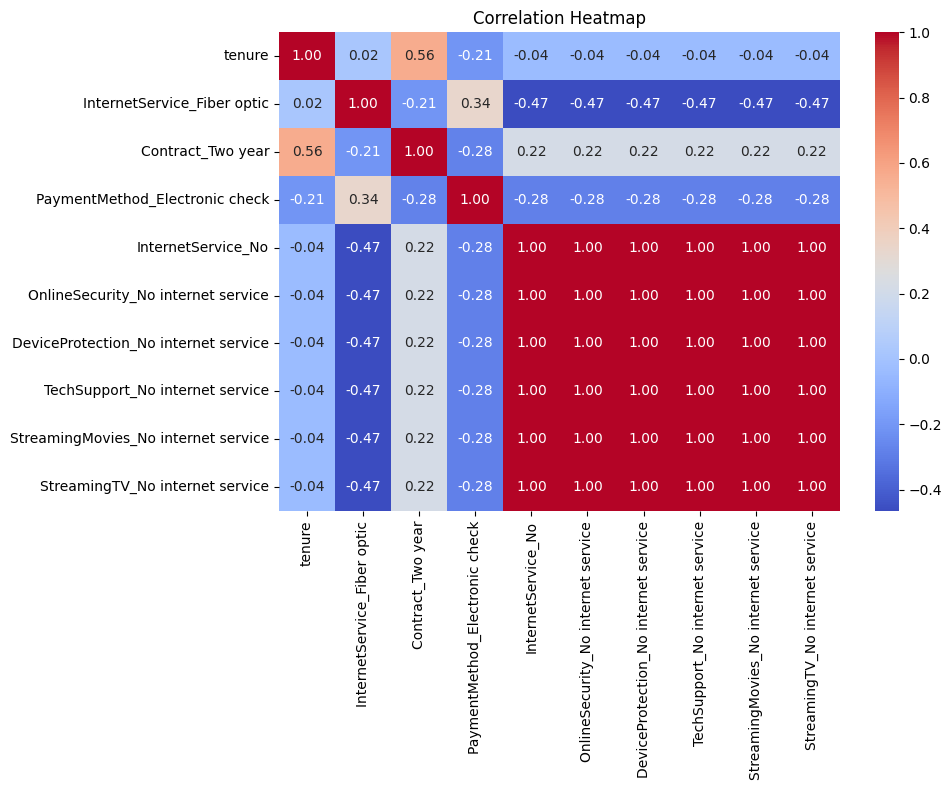

In [5]:
plt.figure(figsize=(10,8))
top_corr = df.corr()['Churn'].abs().sort_values(ascending=False)[1:11].index
sns.heatmap(df[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('images/heatmap.png')
plt.show()

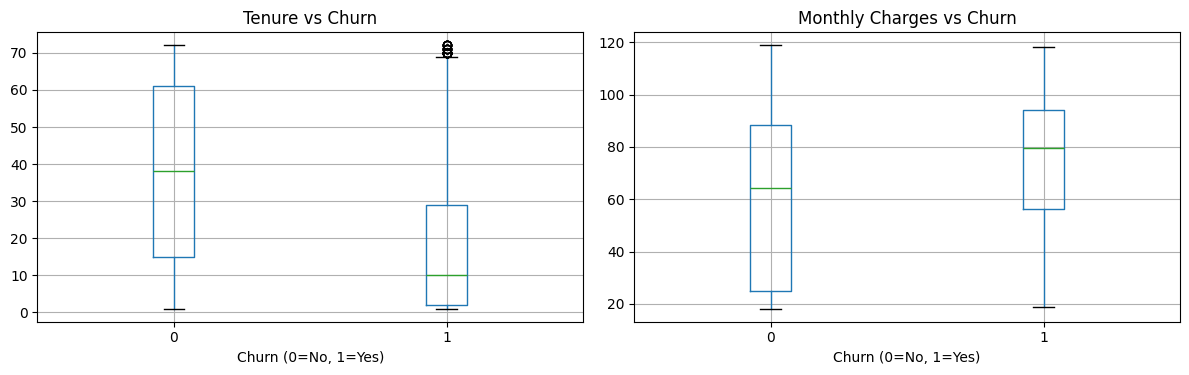

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df.boxplot(column='tenure', by='Churn', ax=axes[0])
axes[0].set_title('Tenure vs Churn')
axes[0].set_xlabel('Churn (0=No, 1=Yes)')

df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')
axes[1].set_xlabel('Churn (0=No, 1=Yes)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('images/tenure_monthly.png')
plt.show()

In [7]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", round(model.score(X_test, y_test)*100, 2), "%")
print(classification_report(y_test, y_pred))

Accuracy: 78.54 %
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



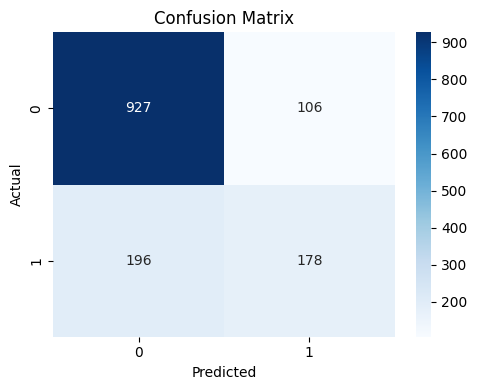

In [8]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png')
plt.show()

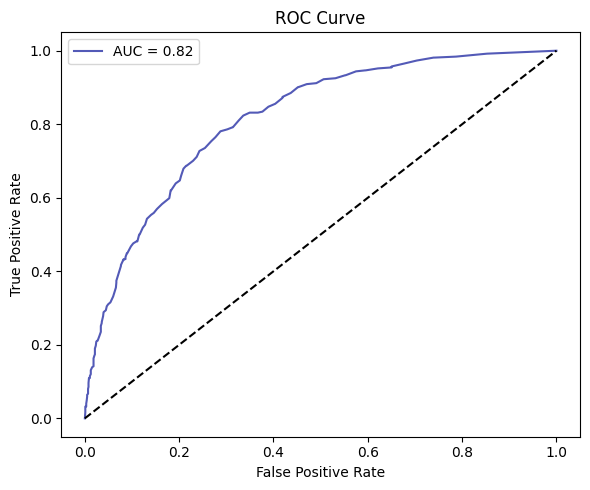

In [10]:
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='#535AB7', label=f'AUC = {auc:.2f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('images/roc_curve.png')
plt.show()

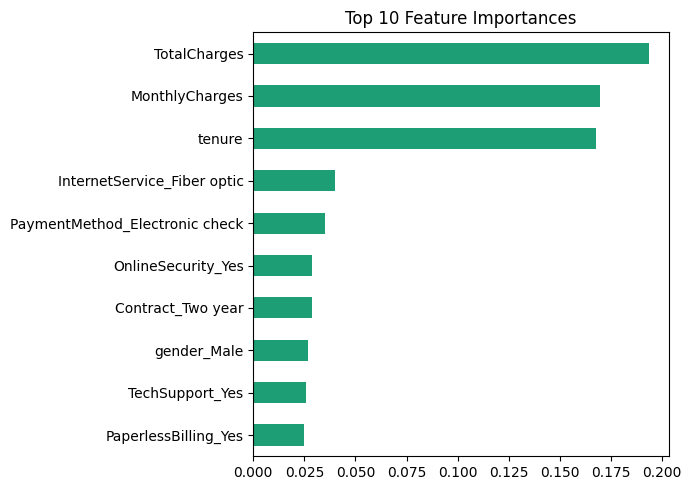

In [11]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]

plt.figure(figsize=(7,5))
feat_imp.plot(kind='barh', color='#1D9E75')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/feature_importance.png')
plt.show()